### 목표 : 프로 선수들의 플레이 스타일과 전투력이 latent space에서 어떻게 구조화되는가?
- 선수 representation 생성
- 플레이 스타일 구조 확인
- PCA component 해석
- robust feature 확인

In [14]:
import pandas as pd 

riot_df = pd.read_csv('최종솔랭_주포지션_매치데이터.csv')

#### Step 1. player-year representation 생성
일단 PCA를 사용할 수 있게 수치형 컬럼들만 골라내고, player-year로 representation 만듦.
그냥 데이터를 바로 사용하면 noise가 너무 크기 때문에 경기들을 평균내서 선수 representation을 생성하자.

In [15]:
# =========================
# PCA용 Riot API 수치형 Feature 선택
# =========================

numeric_features = [

    # 전투
    "kills",
    "deaths",
    "assists",

    "doubleKills",
    "tripleKills",
    "quadraKills",
    "pentaKills",

    # 딜링 / 탱킹
    "totalDamageDealtToChampions",
    "totalDamageTaken",
    "damageSelfMitigated",

    # 군중제어
    "timeCCingOthers",

    # 시야
    "visionScore",
    "wardsPlaced",
    "wardsKilled",
    "visionWardsBoughtInGame",

    # 자원
    "goldEarned",
    "cs",
    "champLevel",

    # 오브젝트
    # "damageDealtToObjectives",
    # "damageDealtToTurrets",

    # "dragonKills",
    # "baronKills",
    # "turretKills",

    # 퍼스트 블러드
    "firstBloodKill",
    "firstBloodAssist",

    # 파생 지표
    "kda",
    "cspm",
    "dpm",

    "earned_gpm",

    "vspm",
    "wpm",
    "wcpm",

    "damagetakenperminute",
    "damagemitigatedperminute"
]


# =========================
# bool -> int 변환
# PCA 전에 숫자로 맞춰줌
# =========================

bool_cols = [
    "win",
    "firstBloodKill",
    "firstBloodAssist"
]

for col in bool_cols:
    riot_df[col] = riot_df[col].astype(int)

# =========================
# 1. 메이저 패치 열 생성
# 세부 패치를 메이저 단위(예: '15')로 묶음
# =========================
riot_df["major_patch"] = riot_df["patch"].astype(str).str.split('.').str[0]


# =========================
# 2. Player-Year-Patch Representation 생성
# 경기 단위 noise 제거 위해 평균 사용
# =========================
player_vectors = (
    riot_df
    .groupby(
        [
            "playername",
            "game_year",
            "major_patch",
            "teamPosition"
        ]
    )[numeric_features]
    .mean()
    .reset_index()
)

# =========================
# 컬럼명 정리 (선택)
# =========================

player_vectors = player_vectors.rename(
    columns={
        "game_year": "year",
        "teamPosition": "position",
        "major_patch": "patch_version",
    }
)

# =========================
# 확인
# =========================

print(player_vectors.shape)

player_vectors.head(3)


(120, 33)


,playername,year,patch_version,position,kills,deaths,assists,doubleKills,tripleKills,quadraKills,...,firstBloodAssist,kda,cspm,dpm,earned_gpm,vspm,wpm,wcpm,damagetakenperminute,damagemitigatedperminute
0,Bdd,2024,14,MIDDLE,7.022059,3.639706,6.529412,0.705882,0.073529,0.0,...,0.132353,3.893041,8.253982,956.511365,474.664364,0.913066,0.349652,0.155968,725.100839,426.758516
1,Bdd,2025,15,MIDDLE,7.272727,4.818182,8.454545,0.818182,0.181818,0.0,...,0.090909,4.574892,7.431432,957.928286,429.433219,0.839336,0.293065,0.128217,843.611257,504.891383
2,BuLLDoG,2026,16,MIDDLE,5.559767,4.099125,6.717201,0.530612,0.058309,0.0,...,0.043732,3.232748,8.720702,895.906730,447.527353,1.124013,0.408267,0.168616,822.275188,507.767486


In [16]:
riot_df.columns

Index(['match_id', 'patch', 'game_date', 'game_year', 'game_month', 'puuid',
       'championName', 'teamPosition', 'win', 'gameDuration', 'kills',
       'deaths', 'assists', 'doubleKills', 'tripleKills', 'quadraKills',
       'pentaKills', 'totalDamageDealtToChampions', 'totalDamageTaken',
       'damageSelfMitigated', 'timeCCingOthers', 'visionScore', 'wardsPlaced',
       'wardsKilled', 'visionWardsBoughtInGame', 'goldEarned', 'champLevel',
       'cs', 'damageDealtToObjectives', 'damageDealtToTurrets', 'dragonKills',
       'baronKills', 'turretKills', 'firstBloodKill', 'firstBloodAssist',
       'kda', 'cspm', 'dpm', 'earned_gpm', 'vspm', 'wpm', 'wcpm',
       'damagetakenperminute', 'damagemitigatedperminute', 'playername',
       'major_patch'],
      dtype='object')

#### Step 2. Standardizaion

In [17]:
from sklearn.preprocessing import StandardScaler

X = player_vectors[numeric_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Step 3. PCA 수행

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

#### Step 4. 1차 latent space 시각화(미드랑 정글을 구분해냄)

* 일단 포지션별로만 PCA를 수행하기에 특별한 결측값처리 , 임계값처리는 하지 않음 

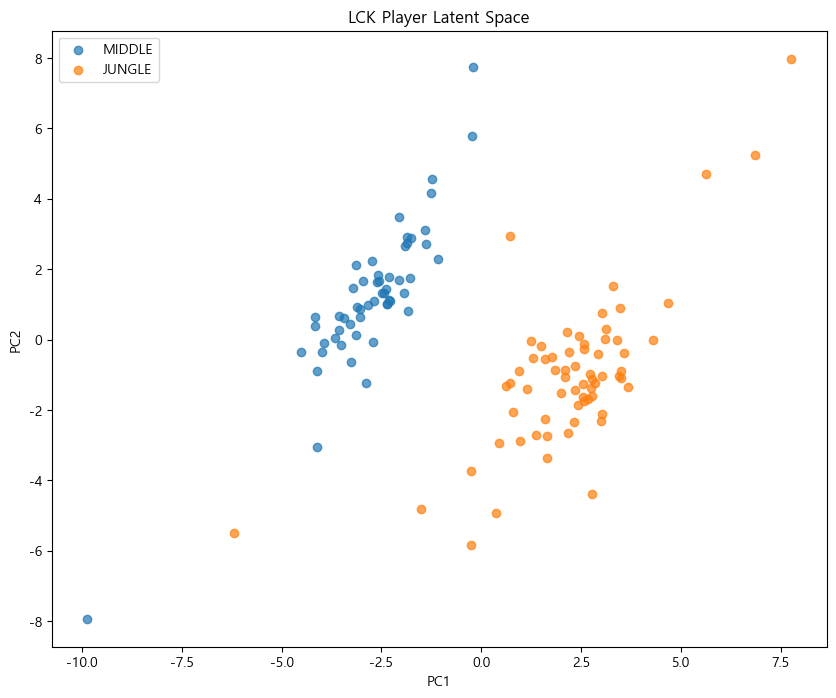

In [19]:
import matplotlib.pyplot as plt

positions = player_vectors["position"].unique()

plt.figure(figsize=(10,8))

for pos in positions:

    idx = (
        player_vectors["position"]
        == pos
    )

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=pos,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "LCK Player Latent Space"
)

plt.legend()

plt.show()

#### Step 5. PCA loading
->PCA1, PCA2가 각각 의미하는게 뭔데...

### 포지션 해석 (전체적인 PCA해보기)
1. 포지션 독립적 축 생성
- PCA는 포지션 정보를 사용하지 않고, 수치형 지표들의 분산과 상관관계만으로 데이터 전체의 주요 변동 축을 추출한다. ( 포지션과 상관없이 설명도의 축을 찾아냄. )

2. 게임 전체의 공통 플레이 스타일 축 도출
- 생성된 PC_1, PC_2, PC_3는 특정 포지션이 아닌, 공격성·지원·생존성과 같은 게임 전반의 잠재 플레이 성향을 나타낸다.

3. 포지션별 군집 구조 형성
- PCA 공간에 선수 데이터를 배치하면, 비슷한 역할군이 자연스럽게 모이며 포지션별 플레이 스타일 차이가 시각적으로 드러난다.

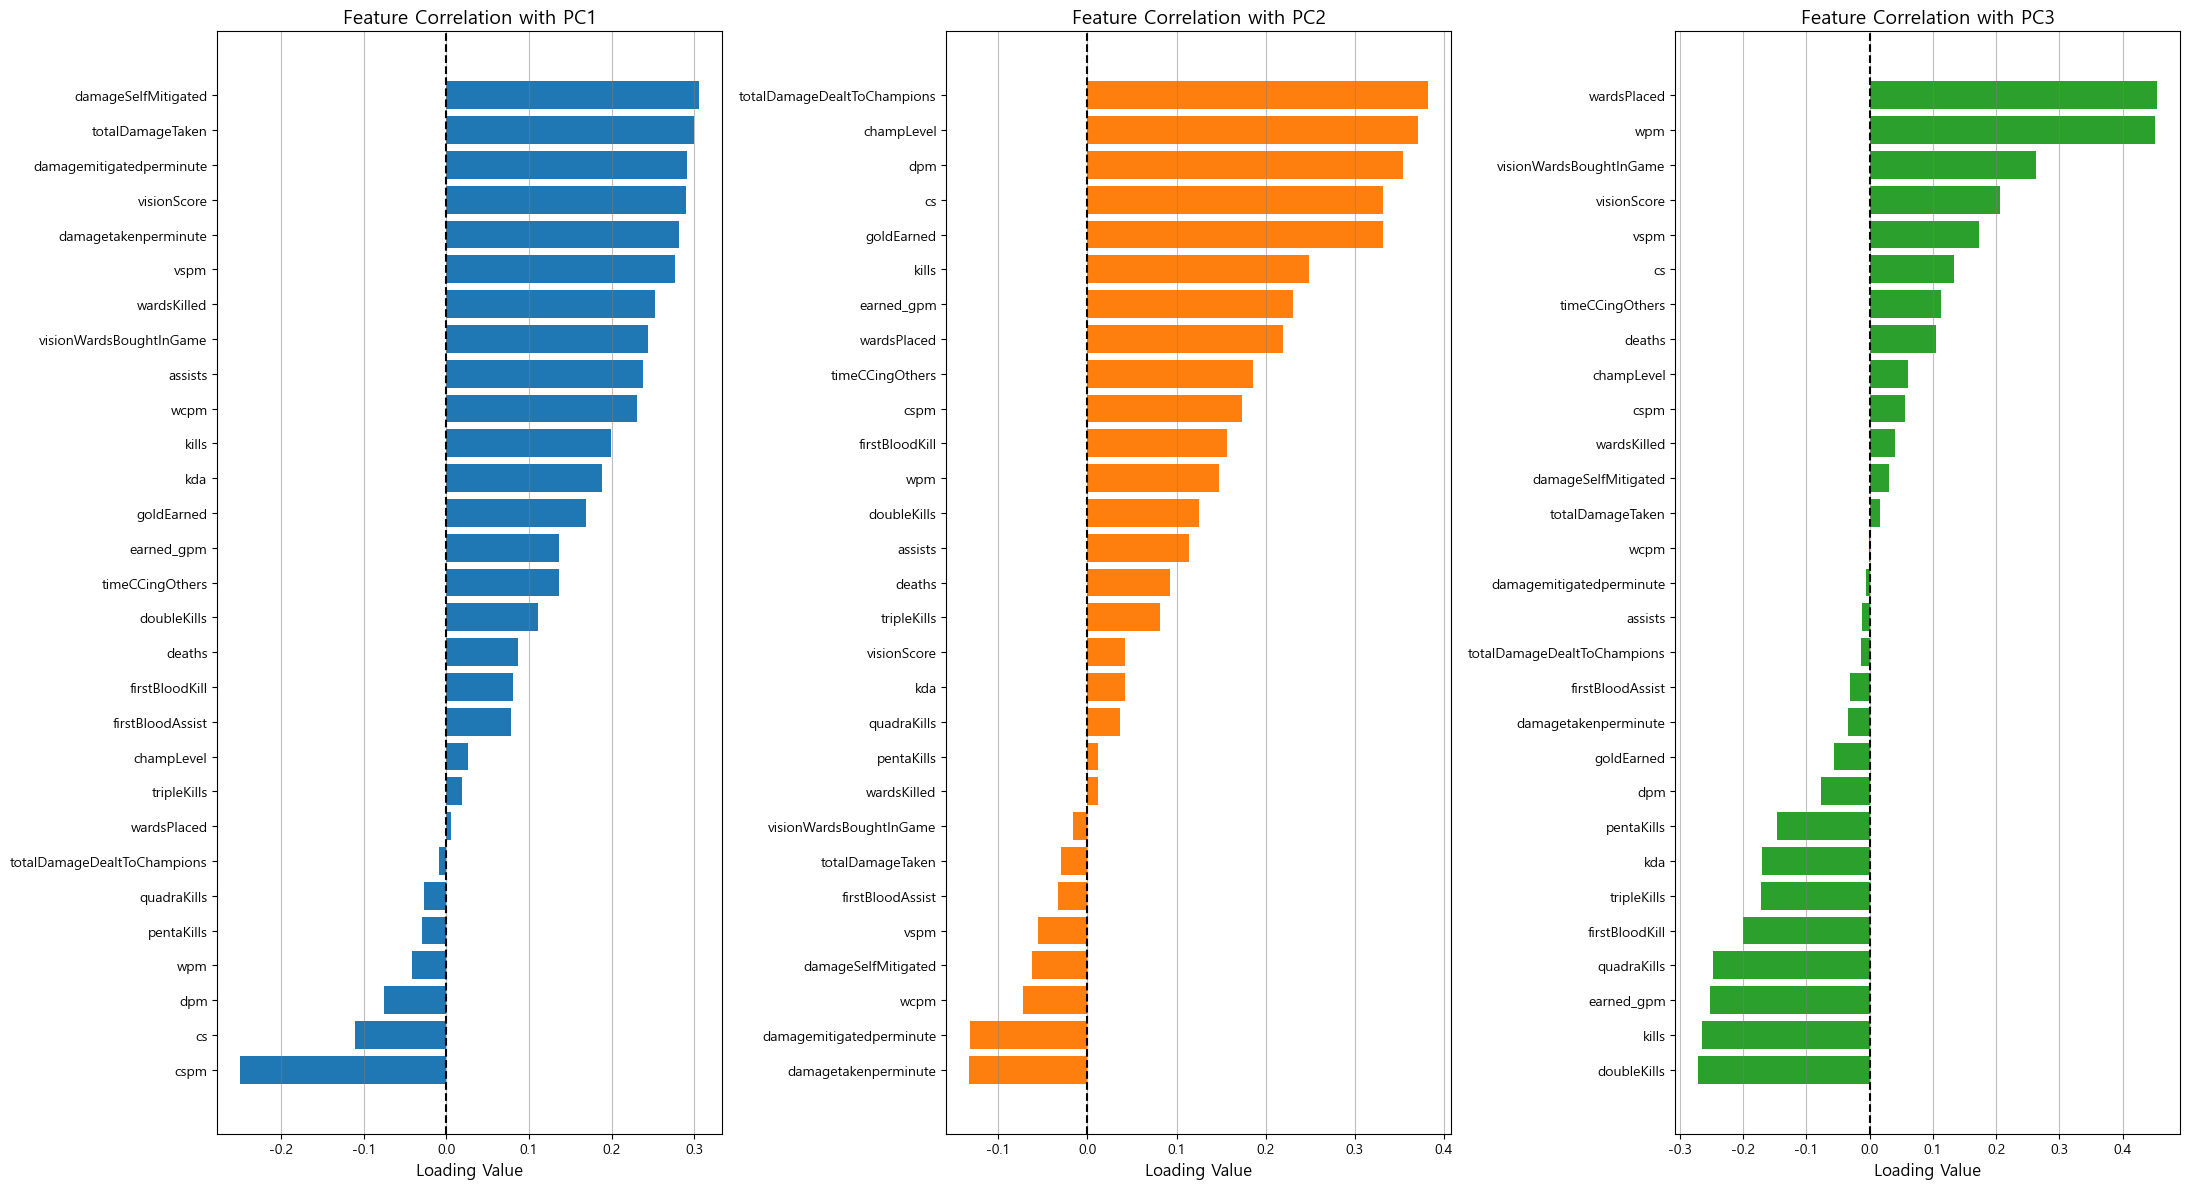

In [23]:
import pandas as pd

# PCA loading dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2","PC3"],
    index=numeric_features
)

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1. PC1, PC2, PC3 데이터 정렬 (오름차순)
# =========================
pc1_sorted = loadings["PC1"].sort_values(ascending=True)
pc2_sorted = loadings["PC2"].sort_values(ascending=True)
pc3_sorted = loadings["PC3"].sort_values(ascending=True)

# =========================
# 2. 1행 3열 도화지 세팅
# 3개를 가로로 길게 배치해서 한눈에 비교
# =========================
fig, axes = plt.subplots(1, 3, figsize=(22, 12))

# --- PC1 그래프 ---
axes[0].barh(pc1_sorted.index, pc1_sorted.values, color='tab:blue')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].grid(axis='x', linestyle='-', color='gray', alpha=0.5)
axes[0].set_title('Feature Correlation with PC1', fontsize=14)
axes[0].set_xlabel('Loading Value', fontsize=12)

# --- PC2 그래프 ---
axes[1].barh(pc2_sorted.index, pc2_sorted.values, color='tab:orange')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].grid(axis='x', linestyle='-', color='gray', alpha=0.5)
axes[1].set_title('Feature Correlation with PC2', fontsize=14)
axes[1].set_xlabel('Loading Value', fontsize=12)

# --- PC3 그래프 ---
axes[2].barh(pc3_sorted.index, pc3_sorted.values, color='tab:green')
axes[2].axvline(0, color='black', linestyle='--')
axes[2].grid(axis='x', linestyle='-', color='gray', alpha=0.5)
axes[2].set_title('Feature Correlation with PC3', fontsize=14)
axes[2].set_xlabel('Loading Value', fontsize=12)

# 간격 자동 조절 및 출력
plt.tight_layout()
plt.show()

1. PC1 — ‘탱커·유틸’ vs ‘딜러·성장’ 축
- 양수 방향은 damageSelfMitigated, totalDamageTaken, visionScore 중심의 전방/서포터 성향을, 음수 방향은 cspm, cs, dpm 중심의 성장형 딜러 성향을 의미한다.


2. PC2 — ‘전투 무력(캐리)’ vs ‘희생형 탱킹’ 축
- 양수 방향은 totalDamageDealtToChampions, champLevel, dpm, kills 기반의 캐리력을, 음수 방향은 damagetakenperminute, damagemitigatedperminute 중심의 탱킹·희생 역할을 나타낸다.


3. PC3 — ‘시야·운영’ vs ‘한타 피지컬’ 축
- 양수 방향은 wardsPlaced, wpm, visionWardsBoughtInGame 기반의 시야·운영 능력을, 음수 방향은 doubleKills, kills, pentaKills, earned_gpm 중심의 한타 피지컬 및 킬 캐치 능력을 의미한다.



### MID 선수들의 latent playstyle 분석

In [26]:
mid_data = player_vectors[
    player_vectors["position"] == "MIDDLE"
].copy()

#### Step 1. 미드 선수들 뽑아내기

In [27]:
print(mid_data.shape)

print(
    mid_data["playername"].unique()[:10]
)

(54, 33)
['Bdd' 'BuLLDoG' 'Calix' 'Chovy' 'Clozer' 'FATE' 'Faker' 'Fisher' 'Karis'
 'Loki']


#### Step 2. MID feature matrix 생성

In [28]:
X_mid = mid_data[numeric_features]

#### STEP 3. Standardization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_mid_scaled = scaler.fit_transform(X_mid)

#### STEP 4. MID 전용 PCA

In [31]:
from sklearn.decomposition import PCA

pca_mid = PCA(n_components=3)

X_mid_pca = pca_mid.fit_transform(
    X_mid_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [32]:
mid_data["PC1"] = X_mid_pca[:,0]
mid_data["PC2"] = X_mid_pca[:,1]
mid_data["PC3"] = X_mid_pca[:,2]

#### STEP 6. MID latent space 시각화

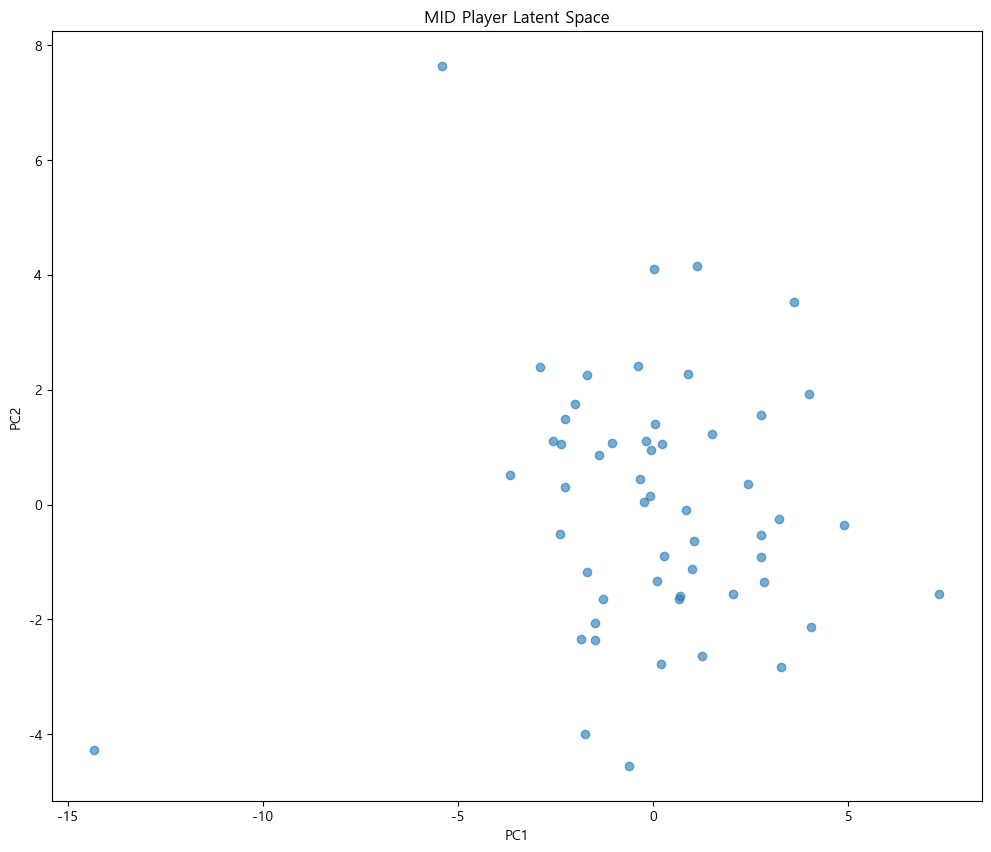

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    mid_data["PC1"],
    mid_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "MID Player Latent Space"
)

plt.show()

#### STEP 7. MID PCA loading 분석

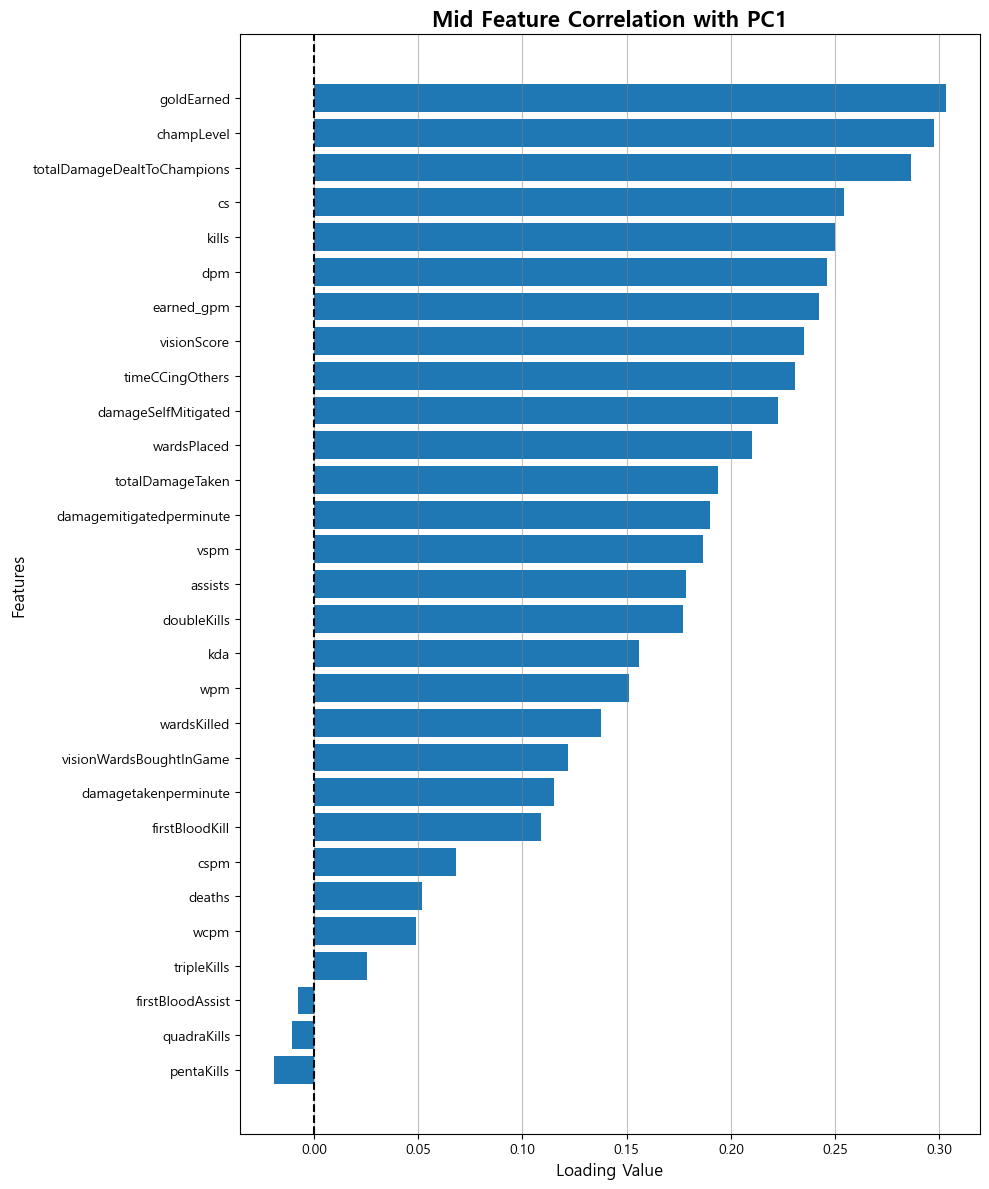

--------------------------------------------------------------------------------


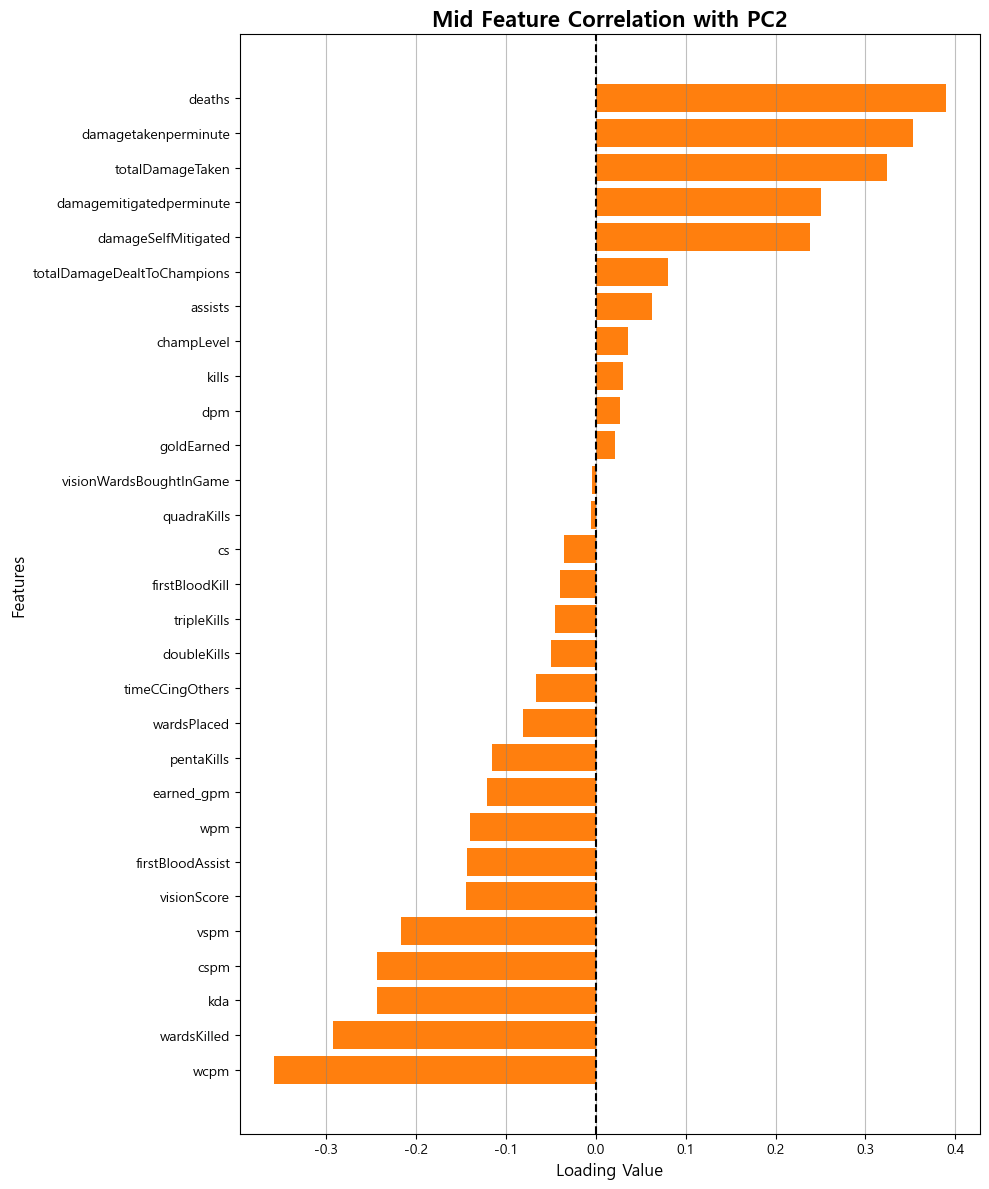

--------------------------------------------------------------------------------


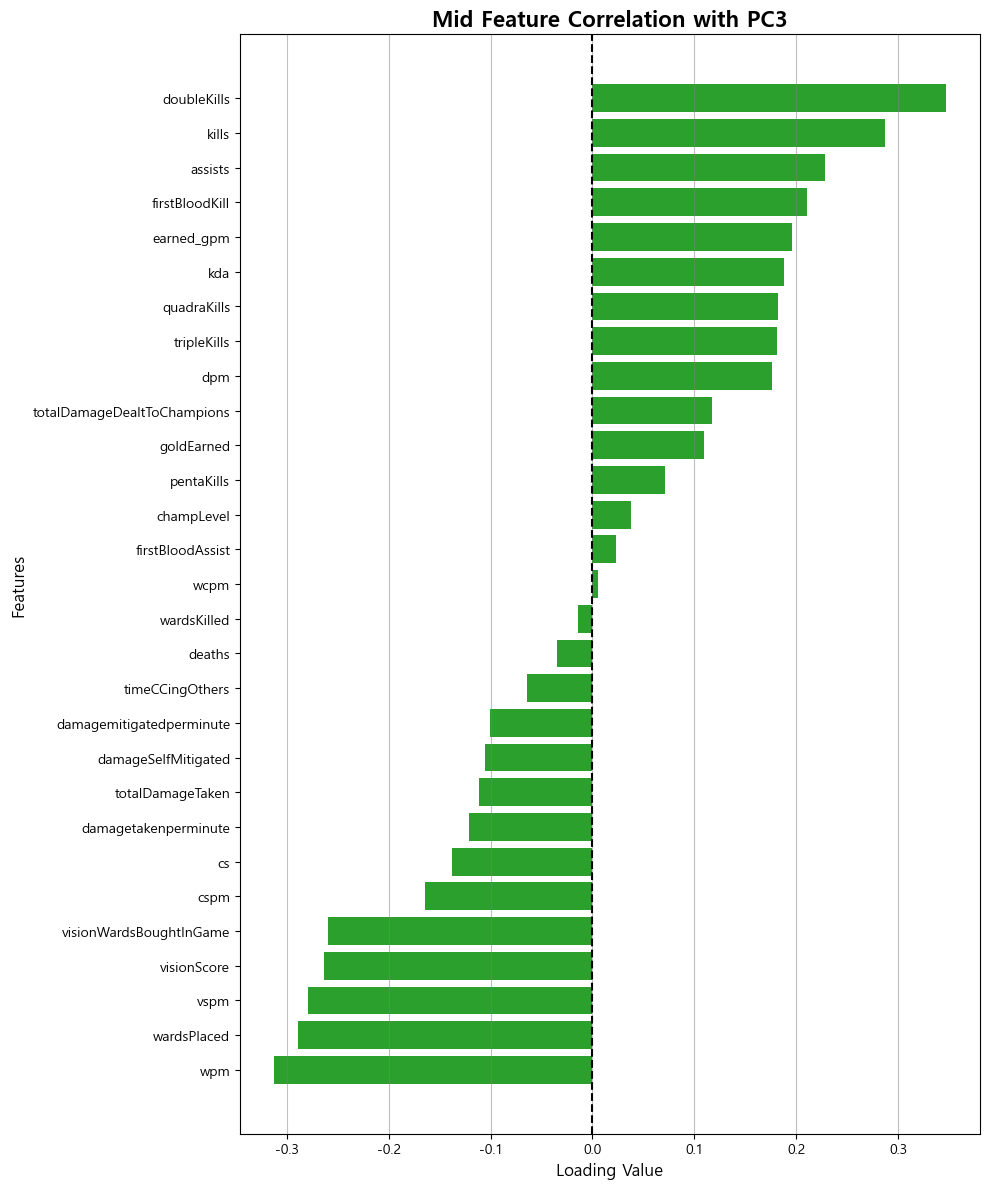

--------------------------------------------------------------------------------


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1. PCA Loading DataFrame 생성
# =========================
loading_df = pd.DataFrame(
    pca_mid.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

# =========================
# 2. for문을 이용한 반복 시각화
# =========================
pc_columns = ["PC1", "PC2", "PC3"]
colors = ["tab:blue", "tab:orange", "tab:green"] # 각 PC별 포인트 컬러

for i, pc in enumerate(pc_columns):
    
    # 해당 PC의 데이터만 추출하여 오름차순 정렬
    pc_sorted = loading_df[pc].sort_values(ascending=True)
    
    # 매 반복마다 새로운 도화지(Figure) 생성 (가로 10, 세로 12)
    plt.figure(figsize=(10, 12))
    
    # 가로 막대 그래프 그리기
    plt.barh(pc_sorted.index, pc_sorted.values, color=colors[i])
    
    # 0 기준선 및 x축 격자선 추가
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
    plt.grid(axis='x', linestyle='-', color='gray', alpha=0.5)
    
    # 축 및 제목 설정
    plt.title(f'Mid Feature Correlation with {pc}', fontsize=16, fontweight='bold')
    plt.xlabel('Loading Value', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    
    plt.tight_layout()
    
    # ★ for문 안에서 show()를 호출하여 각각 독립된 그래프로 출력되게 함
    plt.show() 
    
    print("-" * 80) # 그래프 사이에 구분선 출력 (선택)

### 미드PCA 결과 해석 
---
1. PC1 — ‘성장/캐리’ vs ‘로밍/지원’ 축
- cspm, dpm, goldEarned 중심의 성장·딜링 지표와 assists, timeCCingOthers, visionScore 기반의 합류·유틸리티 지표가 대립하며, “라인 자원을 독점해 캐리하는 스타일”과 “로밍 및 팀 지원 중심 스타일”을 구분하는 축이다.

2. PC2 — ‘암살/변수 창출’ vs ‘안정성/버티기’ 축
- kills, firstBloodKill, doubleKills 등 공격적 킬 캐치 지표와 totalDamageTaken 중심의 안정적 버티기 지표가 대비되며, “폭발적인 암살자형 플레이”와 “라인을 지키며 안정적으로 턴을 받아내는 플레이”를 설명하는 축이다.

3. PC3 — ‘맵 리딩 및 시야 주도권’ 축
- wardsPlaced, visionWardsBoughtInGame, wpm 등 시야 장악 관련 컬럼이 핵심적으로 작용하며, 단순 무력이 아닌 “맵 장악과 운영 중심의 게임 리딩 능력”을 나타내는 축이다.

### Mid PCA분산값 데이터프레임으로 나타내기 

In [38]:
# =========================
# Mid PCA 설명 분산(DataFrame)
# =========================

explained_variance_mid_df = pd.DataFrame({

    "PC": [
        f"PC{i+1}"
        for i in range(
            len(pca_mid.explained_variance_ratio_)
        )
    ],

    "Explained Variance Ratio":
        pca_mid.explained_variance_ratio_,

    "Cumulative Variance Ratio":
        pca_mid.explained_variance_ratio_.cumsum()

})

# 출력
print(explained_variance_mid_df)

    PC  Explained Variance Ratio  Cumulative Variance Ratio
0  PC1                  0.322710                   0.322710
1  PC2                  0.171943                   0.494653
2  PC3                  0.131096                   0.625749



### JGL 선수들의 Latent playstyle 분석

### Step 1. 정글 데이터만 추출

In [39]:
jng_data = player_vectors[
    player_vectors["position"] == "JUNGLE"
].copy()

#### Step 2. PCA 가능하게 Numeric Features만 추출

In [40]:
X_jng = jng_data[numeric_features]

#### Step 3. Standardization

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_jng_scaled = scaler.fit_transform(
    X_jng
)

#### Step 4. PCA 수행

In [44]:
from sklearn.decomposition import PCA

pca_jng = PCA(n_components=3)

X_jng_pca = pca_jng.fit_transform(
    X_jng_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [45]:
jng_data["PC1"] = X_jng_pca[:,0]
jng_data["PC2"] = X_jng_pca[:,1]
jng_data["PC3"] = X_jng_pca[:,2]

#### Step 6. JGL latent space 시각화

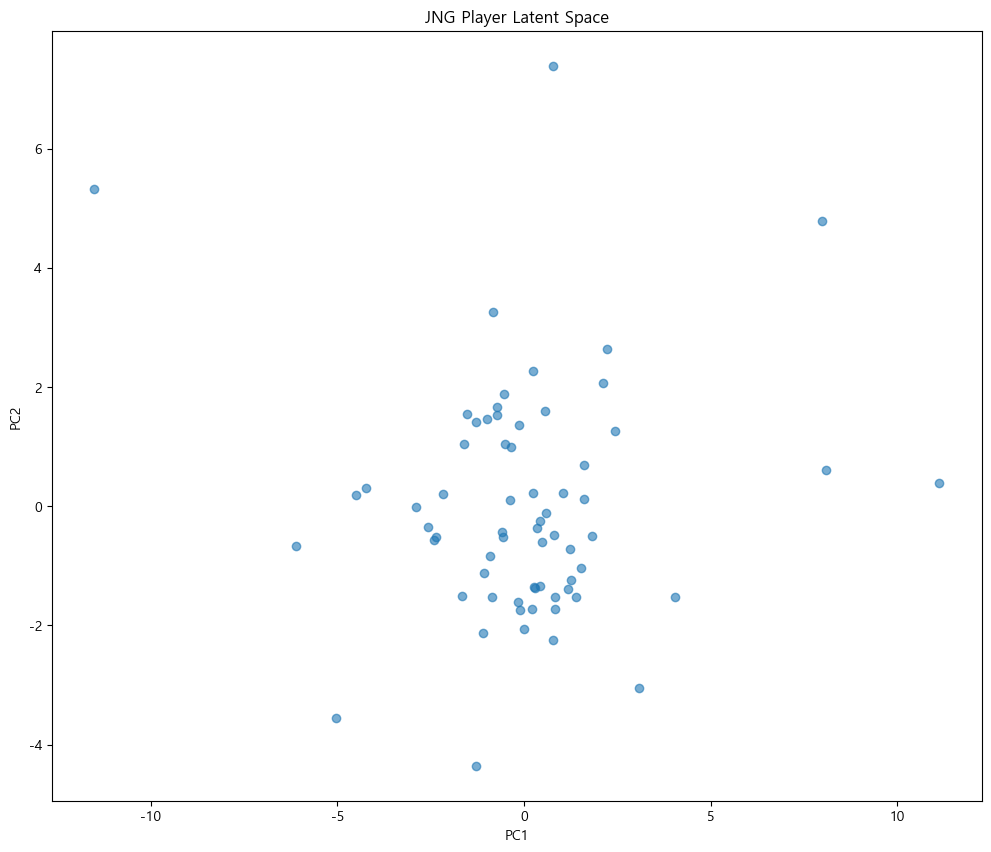

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    jng_data["PC1"],
    jng_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "JNG Player Latent Space"
)

plt.show()

#### Step 7. JGL PCA loading 분석

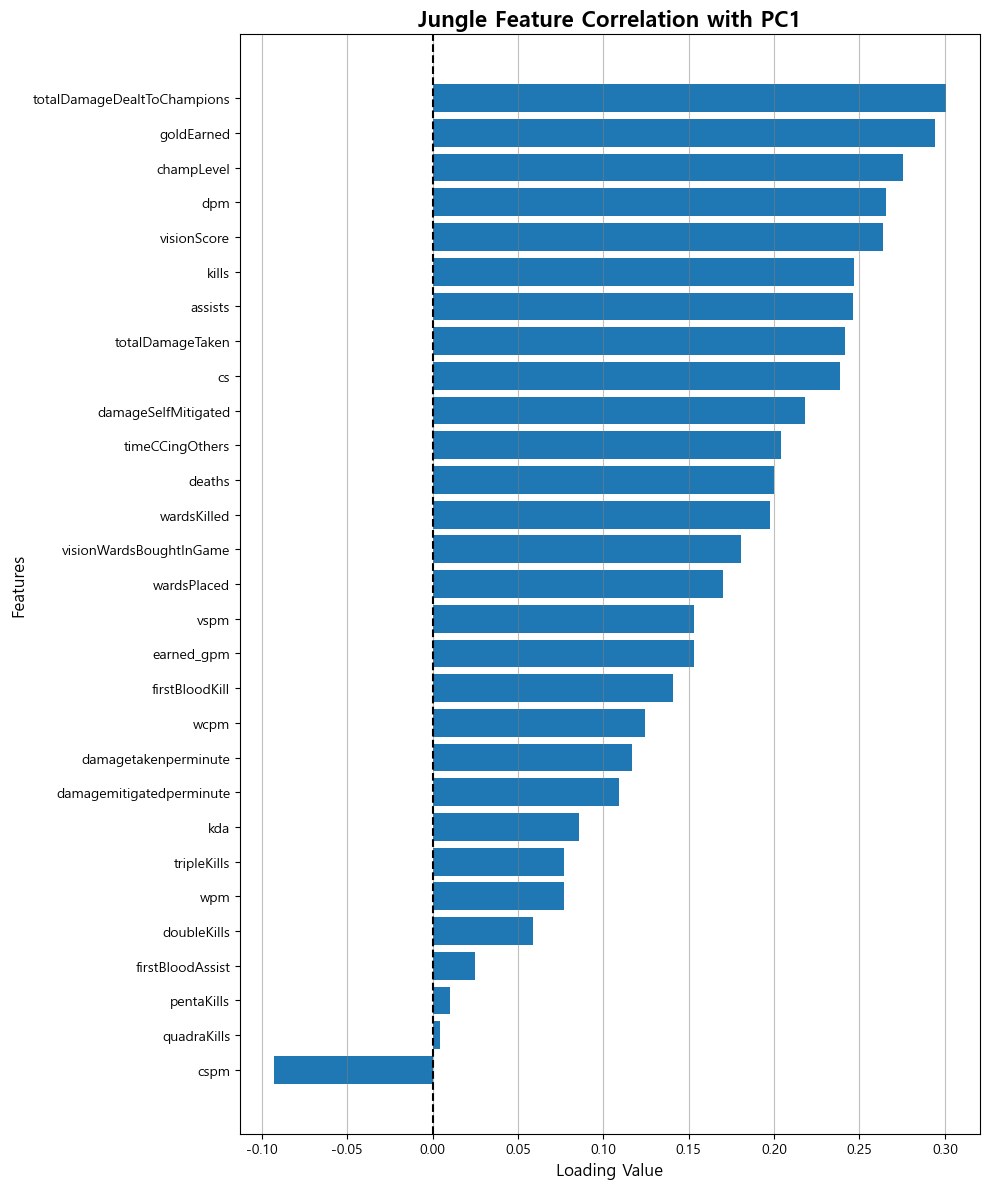

--------------------------------------------------------------------------------


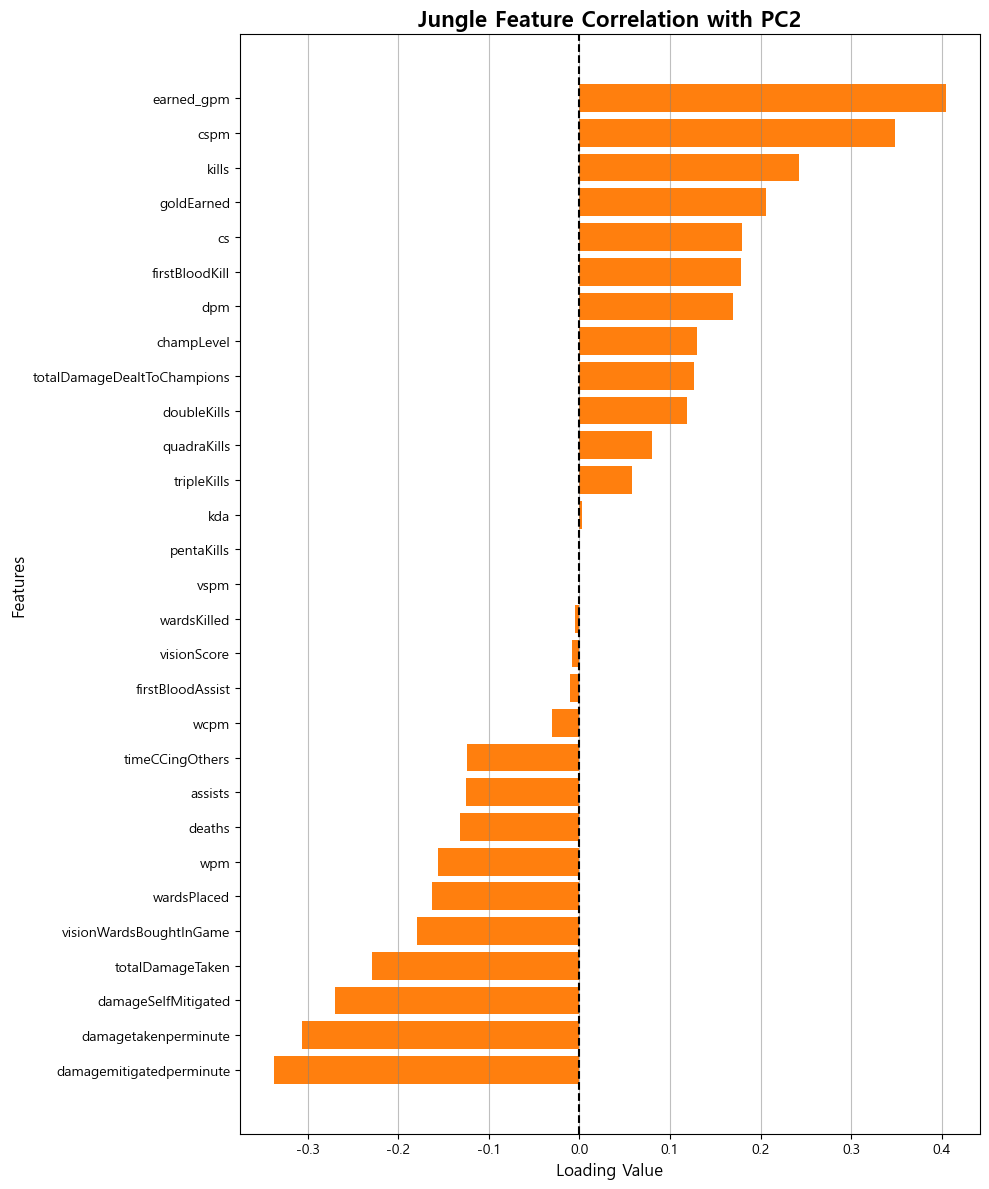

--------------------------------------------------------------------------------


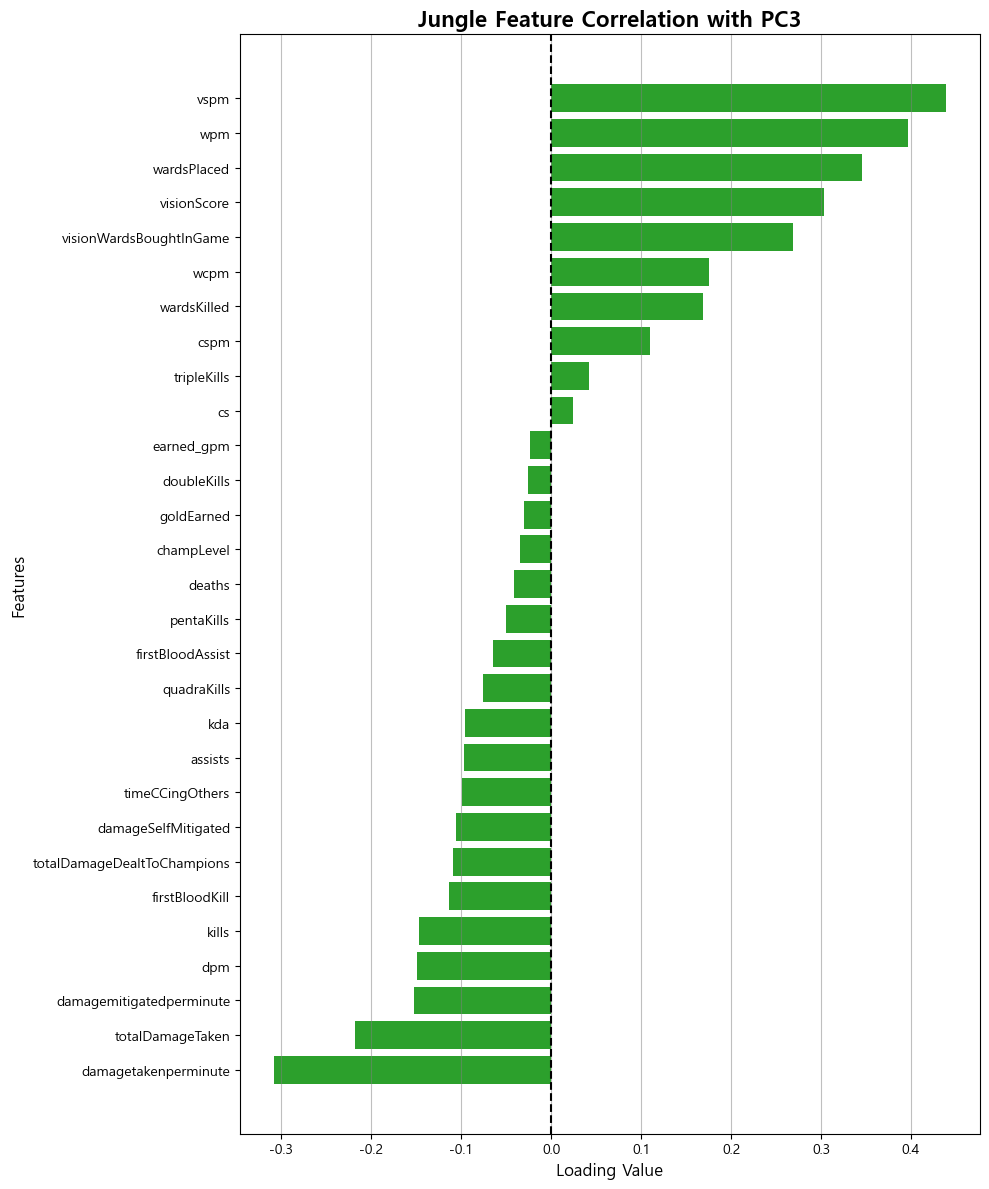

--------------------------------------------------------------------------------


In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1. PCA Loading DataFrame 생성
# =========================
loading_df = pd.DataFrame(
    pca_jng.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

# =========================
# 2. for문을 이용한 반복 시각화
# =========================
pc_columns = ["PC1", "PC2", "PC3"]
colors = ["tab:blue", "tab:orange", "tab:green"] # 각 PC별 포인트 컬러

for i, pc in enumerate(pc_columns):
    
    # 해당 PC의 데이터만 추출하여 오름차순 정렬
    pc_sorted = loading_df[pc].sort_values(ascending=True)
    
    # 매 반복마다 새로운 도화지(Figure) 생성 (가로 10, 세로 12)
    plt.figure(figsize=(10, 12))
    
    # 가로 막대 그래프 그리기
    plt.barh(pc_sorted.index, pc_sorted.values, color=colors[i])
    
    # 0 기준선 및 x축 격자선 추가
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
    plt.grid(axis='x', linestyle='-', color='gray', alpha=0.5)
    
    # 축 및 제목 설정
    plt.title(f'Jungle Feature Correlation with {pc}', fontsize=16, fontweight='bold')
    plt.xlabel('Loading Value', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    
    plt.tight_layout()
    
    # ★ for문 안에서 show()를 호출하여 각각 독립된 그래프로 출력되게 함
    plt.show() 
    
    print("-" * 80) # 그래프 사이에 구분선 출력 (선택)

1. PC1 — ‘전천후 영향력’ vs ‘순수 파밍’ 축
> totalDamageDealtToChampions, goldEarned, champLevel, dpm, kills, assists, visionScore 등이 높은 방향은 게임 전반에 적극 개입하는 올라운드 캐리형 정글을 의미하며, 반대로 cspm 중심 방향은 캠프 성장과 파밍 효율에 집중하는 성향을 나타낸다.

2. PC2 — ‘성장형 캐리’ vs ‘희생형 탱커’ 축
> earned_gpm, cspm, kills, goldEarned 중심의 양수 방향은 자원을 먹고 직접 캐리하는 딜러형 정글을 의미하고, damagemitigatedperminute, damagetakenperminute, damageSelfMitigated, totalDamageTaken 중심의 음수 방향은 몸을 대주며 팀을 보조하는 탱킹·이니시형 정글을 의미한다.

3. PC3 — ‘시야·운영’ vs ‘교전 폭발력’ 축
> vspm, wpm, wardsPlaced, visionScore, visionWardsBoughtInGame 중심의 양수 방향은 맵 장악과 운영 중심 플레이를, dpm, kills, firstBloodKill, totalDamageTaken 중심의 음수 방향은 초반 교전과 킬 캐치 중심의 공격적 정글 스타일을 설명한다.

In [50]:
# =========================
# Mid PCA 설명 분산(DataFrame)
# =========================

explained_variance_jug_df = pd.DataFrame({

    "PC": [
        f"PC{i+1}"
        for i in range(
            len(pca_jng.explained_variance_ratio_)
        )
    ],

    "Explained Variance Ratio":
        pca_jng.explained_variance_ratio_,

    "Cumulative Variance Ratio":
        pca_jng.explained_variance_ratio_.cumsum()

})


print(explained_variance_jug_df)

    PC  Explained Variance Ratio  Cumulative Variance Ratio
0  PC1                  0.314316                   0.314316
1  PC2                  0.131318                   0.445635
2  PC3                  0.114575                   0.560210
